In [3]:
import pylab as plt
import numpy as np
from cartopy import crs as ccrs
from netCDF4 import Dataset
import xarray as xr
from scipy import ndimage
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import h5py  


import sys as sys
import glob as glob
import datetime as datetime
sys.path.append('../src/')

import seismic_LOPS as seismic
import matplotlib.colors as mcolors
import cmocean
import cmocean.cm as cmo
lightcmap = cmo.thermal  #tools.lighten(cmo.deep, 2)

plt.rcParams.update({'font.size': 18,'savefig.facecolor':'white'})

In [8]:
def read_sismo_npz(file):
    '''
    Reads spectromgram from seismic station such as provided by Piero Poli
    note the inconsistency in the "spec" array size and the 'freq" vector 
    this is fixed by cropping the "freq" vector (see last line)
    '''
    data=np.load(file)
    # Base reference date: January 1st, 2023
    base_date = np.datetime64('2023-01-01')

    # Get the float array for time in days since the base date
    t_datenum = data["t_datenum"]- 19358.

    # Subtract 19358 (reference day) and convert to timedelta64 in days
    timedelta = np.array(t_datenum*86400 , dtype='timedelta64[s]')  # Use 'timedelta64[D]'

    # Add timedelta to base_date to get corresponding datetime64 values
    timeo = base_date + timedelta
    print(np.shape( data["spec"]))
    # Return the processed datetime, frequency, and spectrogram data
    #return timeo, data["freq"][20:20+323], data["spec"].T    
    return timeo, data["freq"][0:323], data["spec"].T    

In [9]:


def import_synthetic_mat(file)     :
    '''
    Function to read in a matlab-generated synthetic spectrogram 
    this is used to check the consistency of the original matlab version 
    with this new python version. 
    Will be converted to xarray objects later for easier handling
    '''

    data = h5py.File(file,'r')
    #for k in data.keys():
    #    print(k+' = data["'+k+'"]')
    
    base_date = np.datetime64('2023-01-01')

    # Get the float array for time in days since the base date
    t_datenum = np.array(data["times"])- 738887.

    # Subtract 19358 (reference day) and convert to timedelta64 in days
    timedelta = np.array(t_datenum*86400 , dtype='timedelta64[s]')  # Use 'timedelta64[D]'

    # Add timedelta to base_date to get corresponding datetime64 values
    timeo = base_date + timedelta
    print(timeo[0],timeo[-1])
    freq=np.squeeze(np.array(data['freqp']).T)
    return np.squeeze(timeo),freq,np.array(data['Ef_pris']),np.squeeze(np.array(data['Q'])),np.squeeze(np.array(data['lato'])),np.squeeze(np.array(data['lono']))



In [10]:
wave_spectrum='../data/waves/CCI_WW3-GLOB-30M-Ekoundou_2023_spec.nc'
bottom_topography_spectrum='../data/bottom/spectrum_Ireland_shallow_rocks.bsp'
dpt=30     # adjusts water depth
CgR  =1800 # group speed of seismic waves, assumed constant

ds = Dataset(wave_spectrum, "r")
# list variables in the file
print(ds.variables.keys())
# read the frequency variable
freq = ds.variables["frequency"][:]
lat  = ds.variables["latitude"][0,0]
lon  = ds.variables["longitude"][0,0]
time_spec = ds.variables["time"][:]
date1=time_spec[0]
date2=time_spec[-1]
station='EDA'
dA=1E8*3600
Q=np.array(freq)*0+400
lato, lono, thresh1, thresh2, thresh3, maxd, r, network, startdate=seismic.station_info(freq, station)

F_delta,Fx_delta,Fy_delta,freqp,df,times1=seismic.seismic_response_primary_sandwaves(wave_spectrum, bottom_topography_spectrum, dpt, lat,lon, CgR,  Q,  lono, lato, dA, station)
print('shape:',np.shape(F_delta))

dict_keys(['time', 'station', 'string40', 'station_name', 'longitude', 'latitude', 'frequency', 'frequency1', 'frequency2', 'direction', 'efth', 'dpt', 'wnd', 'wnddir', 'cur', 'curdir'])
alpha: 0.032050896612430074 1.1000000345150478


/home/ardhuin/TOOLS/microseisms_LOPS/scripts/../src/seismic_LOPS.py:155: RuntimeWarning: overflow encountered in square
  FD = -H - X[mask] / np.cosh(X[mask])**2


shape: (2920, 36)


['2023-01-01T00:00:00'] ['2023-12-31T21:00:00']
['2023-01-01T00:00:00'] ['2023-12-31T21:00:00']
(53, 5400)
FRQ: (53,) [0.01166667 0.01333333 0.015      0.01666667 0.01833333 0.02
 0.02166667 0.02333333 0.025      0.02666667 0.02833333 0.03
 0.03166667 0.03333333 0.035      0.03666667 0.03833333 0.04
 0.04166667 0.04333333 0.045      0.04666667 0.04833333 0.05
 0.05166667 0.05333333 0.055      0.05666667 0.05833333 0.06
 0.06166667 0.06333333 0.065      0.06666667 0.06833333 0.07
 0.07166667 0.07333333 0.075      0.07666667 0.07833333 0.08
 0.08166667 0.08333333 0.085      0.08666667 0.08833333 0.09
 0.09166667 0.09333333]
SPEC: (5400, 53)
2023-01-01T00:00:00 2023-01-01T01:00:00 2024-01-01T22:59:59
(5400, 53) (5400,) (36,)
(2920, 36) (2920,) (36,)
(2920, 36) (2920,) (36,)


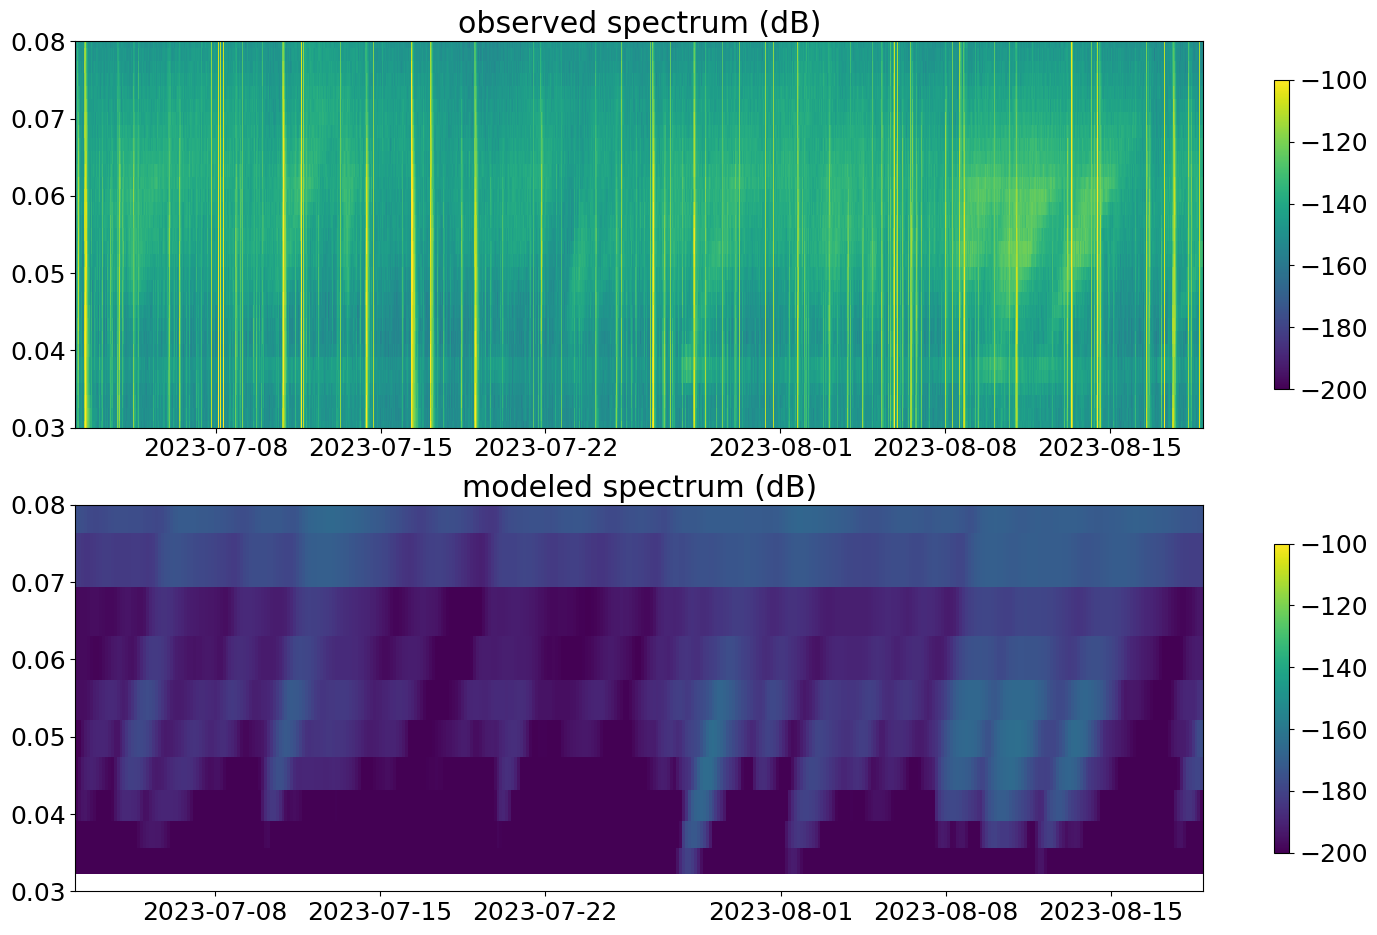

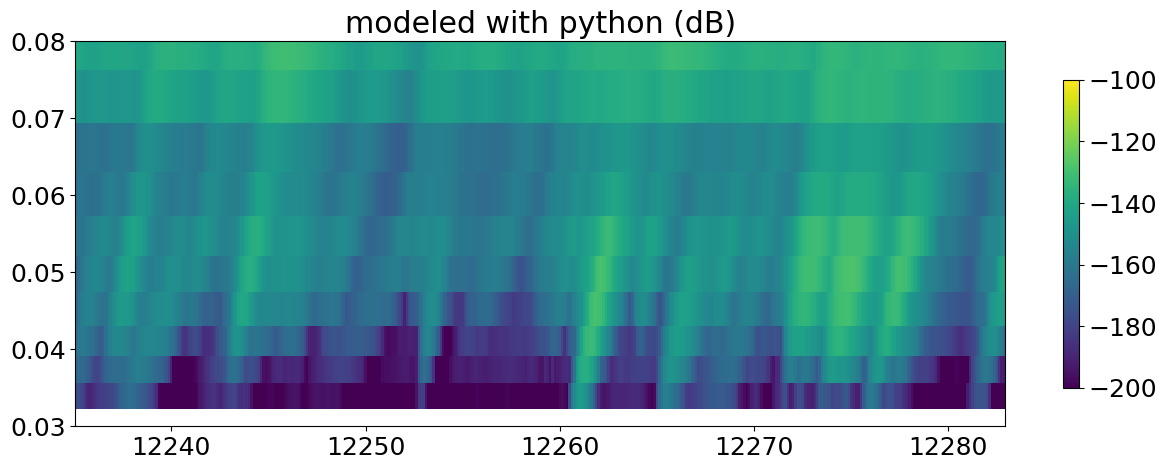

In [11]:
#times,freqp,Ef_pris,Q,lato,lono=import_synthetic_mat('EDA_PDC_GLOBAL05_202301_TEST471_REF102040Q400_150_primary.mat')
times,freqp,Ef_pris,Q,lato,lono=import_synthetic_mat('../results/EDA_IRL_GLOBAL05_202301_CCI_WW3_Ekoundou_Q400_030_primary.mat')
times,freqp,Ef_pri2,Q,lato,lono=import_synthetic_mat('../results/EDA_IRL_GLOBAL05_202301_CCI_WW3_Akpo_Q400_200_primary.mat')

# Warning: data from Piero is probably PSD of acceleration ... 
file='../data/SpecEDA2023_psd.npz' # 'SpecEDA2023.npz'
date0, frq0, spectre0=read_sismo_npz(file)
print('FRQ:',np.shape(frq0),frq0[0:50])
print('SPEC:',np.shape(spectre0))
t1=np.datetime64('2023-07-02')
t2=np.datetime64('2023-08-19')
inds=np.where((date0 > t1) & (date0 < t2))[0]
print(date0[0],date0[1],date0[-1])
np.datetime64('2023-01-01')
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(15,10))
plt.subplots_adjust(left=0.05,bottom=0.07, top=0.92,wspace=0.12,right=0.99)
#im=ax[0].pcolormesh(10*np.log10(np.squeeze(spectre0)),cmap='viridis',rasterized=True) #,vmin=10, vmax=60)
print(np.shape(spectre0),np.shape(date0),np.shape(freqp))
im=ax[0].pcolormesh(date0[inds],frq0,10*np.log10(spectre0[inds,:].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax[0],label='', location='right',shrink=0.8)
_=ax[0].set_title('observed spectrum (dB)')
#_=ax[0].set_ylim([0.03,0.08])
_=ax[0].set_ylim([0.03,0.08])

print(np.shape(Ef_pris),np.shape(times),np.shape(freqp))
indsm=np.where((times > t1) & (times < t2))[0]
im=ax[1].pcolormesh(times[indsm],freqp[0:10],10*np.log10(Ef_pris[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax[1],label='', location='right',shrink=0.8)
_=ax[1].set_title('modeled spectrum (dB)')
_=ax[1].set_ylim([0.03,0.08])


fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
print(np.shape(F_delta),np.shape(times),np.shape(freqp))
indsm=np.where((times > t1) & (times < t2))[0]
im=ax.pcolormesh(times1[indsm],freqp[0:10],10*np.log10(F_delta[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

In [12]:
freqs=freqp
dfs=freqp*0.5*(1.1-1/1.1)
rs=dfs*0
print(lato,lono,freqs.shape)
# Set up paths
station='EDA' 
year=2023
yname = str(year)  # Replace with your desired year
#lato, lono, thresh1, thresh2, thresh3, maxd, rs, network, startdate=seismic.station_info(freqs, station)

ifmin = 1  # 0.1 
ifmax = 5 # 0.25

#ifmin = 5  # 0.1 
#ifmax = 8 # 0.25

print('Freq:',freqs[ifmin]*0.95,freqs[ifmax-1]*1.05)
# Assuming `date0` and `times` are datetime64 objects
base_date = np.datetime64('1970-01-01')  # You can use any base date, like '1970-01-01'

# Convert `date0` and `times` into seconds since the base date (this assumes `date0` and `times` are datetime64)
date0_seconds = (date0 - base_date) / np.timedelta64(1, 's')
times_seconds = (times - base_date) / np.timedelta64(1, 's')

# Now you can safely divide them by np.timedelta64(1, 's') if needed
delta_obs = seismic.compute_delta_obs(spectre0, frq0, freqs, ifmin, ifmax, date0_seconds, times_seconds,smooth=2,percentile=0)
delta_Eko, delta_ref = seismic.compute_delta_model(Ef_pris, Ef_pris, dfs, rs, ifmin, ifmax)
delta_Eko2, delta_ref = seismic.compute_delta_model(F_delta, F_delta, dfs, rs, ifmin, ifmax)
delta_Akp, delta_ref = seismic.compute_delta_model(Ef_pri2, Ef_pri2, dfs, rs, ifmin, ifmax)





3.778868 10.153427 (36,)
Freq: 0.03542549945414066 0.05211463831365109
df2: (2920, 36)
df2: (2920, 36)
df2: (2920, 36)


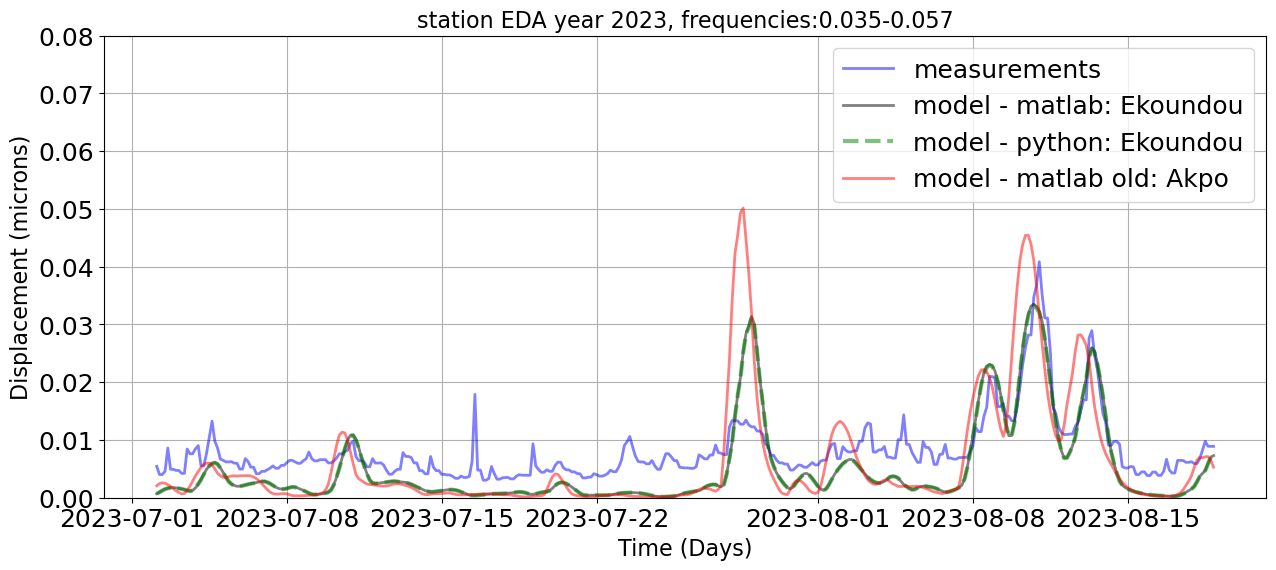

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,6))
P=60

t1=np.datetime64('2023-07-02')
t2=np.datetime64('2023-08-19')
inds=np.where((times > t1) & (times < t2))[0]

ax.plot(times[inds], delta_obs[inds], 'b-',alpha=0.5, label='measurements', linewidth=2)
ax.plot(times[inds], delta_Eko[inds] * P, 'k-', alpha=0.5,label='model - matlab: Ekoundou', linewidth=2)
ax.plot(times[inds], delta_Eko2[inds] , 'g--', alpha=0.5,label='model - python: Ekoundou', linewidth=3)
ax.plot(times[inds], delta_Akp[inds] * P, 'r-', alpha=0.5,label='model - matlab old: Akpo', linewidth=2)
#ax.plot(times, delta_PDC * P, 'k-', alpha=0.5,label='model: sandwaves', linewidth=2)
ax.set_xlabel('Time (Days)', fontsize=16)
ax.set_ylabel('Displacement (microns)', fontsize=16)
ax.set_ylim([0,0.08])
freqstring=f'{freqs[ifmin]*0.95:4.3f}'+'-'+f'{freqs[ifmax]*1.05:4.3f}'
ax.set_title('station '+station+' year '+yname+ ', frequencies:'+freqstring, fontsize=16)
plt.legend()
plt.grid(True)
        
plt.savefig('timeseries_freqs_newEDA'+freqstring+'.png')


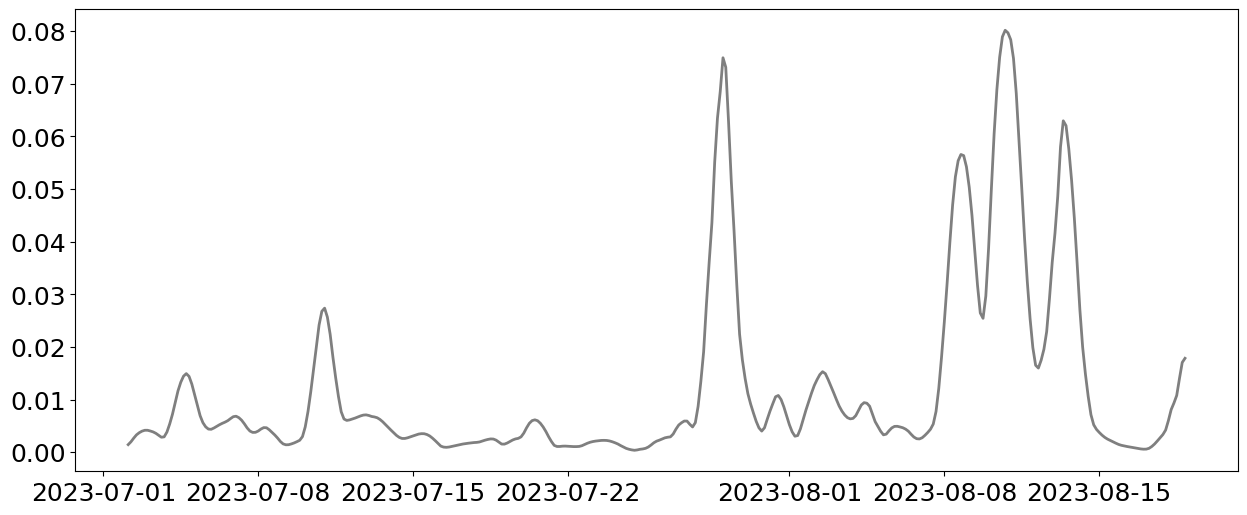

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,6))
P=70
inds=np.where((times > t1) & (times < t2))[0]
#ax.plot(times[inds], delta_obs[inds], 'b-',alpha=0.5, label='measurements', linewidth=2)
ax.plot(times[inds], delta_Eko[inds] * P*3, 'k-', alpha=0.5,label='model: Ekoundou', linewidth=2)
